### Neural Radiance Field!
### Part 0: Calibrating Your Camera and Capturing a 3D Scan
For the first part of the assignment, you will take a 3D scan of your own object which you will build a NeRF of later! To do this, we will use visual tracking targets called ArUco tags, which provide a way to reliably detect the same 3D keypoints across different images. There are 2 parts: 1) calibrating your camera parameters, and 2) using them to estimate pose. This part can be done entirely locally on your laptop, no need for a GPU. We will be using many helper functions from OpenCV, which you can install with pip install opencv-python.

### Part 0.1: Calibrating Your Camera
First, either print out the following calibration tags or pull them up on a laptop/iPad screen. Capture 30-50 images of these tags from your phone camera, keeping the zoom the same. While capturing, results will be best if you vary the angle/distance of the camera, like shown in chessboard calibration in lecture.

Note: For the purpose of this assignment, phone cameras work better since they provide undistorted images without lens effects. If you use a real camera, try to make sure there are no distortion effects.

Now you'll write a script to calibrate your camera using the images you captured. Here's the pipeline:

Loop through all your calibration images
For each image, detect the ArUco tags using OpenCV's ArUco detector
Extract the corner coordinates from the detected tags
Collect all detected corners and their corresponding 3D world coordinates (you can consider the ArUco tag as the world origin and define the 4 corners' 3D points relative to that, e.g., if your tag is 0.02m × 0.02m, the corners could be [(0,0,0), (0.02,0,0), (0.02,0.02,0), (0,0.02,0)])
Use cv2.calibrateCamera() to compute the camera intrinsics and distortion coefficients
Important: Your code should handle cases where tags aren't detected in some images (this is common). Make sure to check if tags were found before trying to use the detection results, otherwise your script will crash.

In [2]:
import cv2
import numpy as np
import glob
import os
from pathlib import Path

def calibrate_camera(images_path, tag_size=0.06, output_file="camera_calibration.npz"):
    """
    Calibrate camera using ArUco tags
    
    Args:
        images_path: Path to folder containing calibration images
        tag_size: Size of ArUco tag in meters (default 6cm)
        output_file: File to save calibration results
    """
    
    # Create ArUco dictionary and detector parameters (4x4 tags)
    aruco_dict = cv2.aruco.getPredefinedDictionary(cv2.aruco.DICT_4X4_50)
    aruco_params = cv2.aruco.DetectorParameters()
    detector = cv2.aruco.ArucoDetector(aruco_dict, aruco_params)
    
    # Arrays to store object points and image points from all images
    all_obj_points = []  # 3D points in real world space
    all_img_points = []  # 2D points in image plane
    all_corners = []     # Store corners for each image
    all_ids = []         # Store IDs for each image
    
    # Define the 3D coordinates of the ArUco tag corners
    # Assuming tag lies in the XY plane (Z=0)
    objp = np.zeros((4, 3), dtype=np.float32)
    objp[:, :2] = np.array([
        [0, 0],
        [tag_size, 0],
        [tag_size, tag_size],
        [0, tag_size]
    ], dtype=np.float32)
    
    # Get list of image files
    image_files = glob.glob(os.path.join(images_path, "*.jpg")) + \
                  glob.glob(os.path.join(images_path, "*.png")) + \
                  glob.glob(os.path.join(images_path, "*.jpeg"))
    
    print(f"Found {len(image_files)} images for calibration")
    
    valid_images = 0
    
    for i, image_file in enumerate(image_files):
        print(f"Processing image {i+1}/{len(image_files)}: {os.path.basename(image_file)}")
        
        # Read image
        image = cv2.imread(image_file)
        if image is None:
            print(f"  Warning: Could not read {image_file}, skipping")
            continue
            
        gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
        
        # Detect ArUco markers
        corners, ids, rejected = detector.detectMarkers(gray)
        
        # Check if any markers were detected
        if ids is not None and len(ids) > 0:
            print(f"  Detected {len(ids)} markers")
            
            # Prepare object points and image points for this image
            img_points = []
            obj_points = []
            
            # For each detected marker
            for j, marker_id in enumerate(ids):
                # Add the 4 corner points for this marker
                img_points.extend(corners[j][0])
                
                # Add corresponding 3D points
                obj_points.extend(objp)
            
            # Convert to numpy arrays
            img_points = np.array(img_points, dtype=np.float32)
            obj_points = np.array(obj_points, dtype=np.float32)
            
            # Store for calibration
            all_obj_points.append(obj_points)
            all_img_points.append(img_points)
            all_corners.append(corners)
            all_ids.append(ids)
            
            valid_images += 1
            
            # Optional: Visualize detected markers
            image_with_markers = cv2.aruco.drawDetectedMarkers(image.copy(), corners, ids)
            # cv2.imshow('Detected Markers', image_with_markers)
            # cv2.waitKey(100)  # Display for 100ms
            import matplotlib.pyplot as plt
            # plt.imshow(cv2.cvtColor(image_with_markers, cv2.COLOR_BGR2RGB))
            # plt.title("Detected Markers")
            # plt.axis("off")
            # plt.show()

            
        else:
            print(f"  No markers detected in {os.path.basename(image_file)}, skipping")
    
    # cv2.destroyAllWindows()
    
    print(f"\nSuccessfully processed {valid_images} images with markers")
    
    if valid_images < 10:
        print("Warning: Need at least 10 images with detected markers for good calibration!")
        if valid_images == 0:
            print("No valid images found. Check your images and ArUco detection.")
            return None
    
    # Perform camera calibration
    print("Performing camera calibration...")
    ret, camera_matrix, dist_coeffs, rvecs, tvecs = cv2.calibrateCamera(
        all_obj_points, all_img_points, gray.shape[::-1], None, None
    )
    
    # Print calibration results
    print(f"\n=== CALIBRATION RESULTS ===")
    print(f"Reprojection error: {ret:.4f}")
    print(f"Camera matrix:")
    print(camera_matrix)
    print(f"Distortion coefficients: {dist_coeffs.ravel()}")
    
    # Calculate and print reprojection errors per image
    print(f"\nReprojection errors per image:")
    mean_errors = []
    for i in range(len(all_obj_points)):
        img_points2, _ = cv2.projectPoints(all_obj_points[i], rvecs[i], tvecs[i], 
                                         camera_matrix, dist_coeffs)
        img_points2 = img_points2.reshape(-1, 2)
        error = cv2.norm(all_img_points[i], img_points2, cv2.NORM_L2) / len(img_points2)
        mean_errors.append(error)
        print(f"  Image {i+1}: {error:.4f}")
    
    print(f"Mean reprojection error: {np.mean(mean_errors):.4f}")
    
    # Save calibration results
    np.savez(output_file, 
             camera_matrix=camera_matrix, 
             dist_coeffs=dist_coeffs,
             rvecs=rvecs,
             tvecs=tvecs,
             image_size=gray.shape[::-1])
    
    print(f"\nCalibration results saved to {output_file}")
    
    return camera_matrix, dist_coeffs

def load_calibration(calibration_file):
    """Load previously saved calibration data"""
    data = np.load(calibration_file)
    return data['camera_matrix'], data['dist_coeffs']

In [3]:
if __name__ == "__main__":
    # Example usage
    images_folder = "calibration_tags"  # Change this to your images folder
    calibration_file = "camera_calibration.npz"
    
    # Calibrate camera
    camera_matrix, dist_coeffs = calibrate_camera(images_folder, output_file=calibration_file)
    
    if camera_matrix is not None:
        
        # Load and verify saved calibration
        print("\nLoading saved calibration...")
        loaded_matrix, loaded_dist = load_calibration(calibration_file)
        print("Loaded camera matrix:")
        print(loaded_matrix)
        print("Loaded distortion coefficients (should be near zero for phone):")
        print(loaded_dist.ravel())


Found 31 images for calibration
Processing image 1/31: IMG_2176.jpg
  Detected 6 markers
Processing image 2/31: IMG_2177.jpg
  Detected 6 markers
Processing image 3/31: IMG_2178.jpg
  Detected 6 markers
Processing image 4/31: IMG_2179.jpg
  Detected 6 markers
Processing image 5/31: IMG_2180.jpg
  Detected 6 markers
Processing image 6/31: IMG_2181.jpg
  Detected 6 markers
Processing image 7/31: IMG_2182.jpg
  Detected 6 markers
Processing image 8/31: IMG_2183.jpg
  Detected 6 markers
Processing image 9/31: IMG_2184.jpg
  Detected 6 markers
Processing image 10/31: IMG_2185.jpg
  Detected 6 markers
Processing image 11/31: IMG_2186.jpg
  Detected 6 markers
Processing image 12/31: IMG_2187.jpg
  Detected 6 markers
Processing image 13/31: IMG_2188.jpg
  Detected 6 markers
Processing image 14/31: IMG_2189.jpg
  Detected 6 markers
Processing image 15/31: IMG_2190.jpg
  Detected 6 markers
Processing image 16/31: IMG_2191.jpg
  Detected 6 markers
Processing image 17/31: IMG_2192.jpg
  Detected 6

### Part 0.2: Capturing a 3D Object Scan
Next, pick a favorite object of yours, and print out a single ArUco tag, which you can generate from here. Place the object next to the tag on a tabletop, and capture 30-50 images of the object from different angles. Important: Use the same camera and zoom level as you did for calibration. If you cut out the ArUco tag from a piece of paper, make sure to leave a white border around it, otherwise detection will fail.

Capture tips for good quality NeRF results later:

1. Avoid brightness/exposure changes (this is why printing the tag will work better than using a tablet display)
2. Avoid blurry images, try not to introduce motion blur
3. Capture images at varying angles horizontally and vertically
4. Capture images at one uniform distance, about 10-20cm away from the object so that it fills ~50% of the frame

In [4]:
import cv2
import numpy as np
import glob
import os
import json
from pathlib import Path

def estimate_poses(images_path, calibration_file, tag_size=0.06, output_file="camera_poses.json"):
    """
    Estimate camera poses for object scan images using ArUco tag
    
    Args:
        images_path: Path to folder containing object scan images
        calibration_file: File with camera calibration data
        tag_size: Size of ArUco tag in meters (default 0.06m = 60mm)
        output_file: File to save camera poses
    """
    
    # Load camera calibration
    calibration_data = np.load(calibration_file)
    camera_matrix = calibration_data['camera_matrix']
    dist_coeffs = calibration_data['dist_coeffs']
    
    # Create ArUco dictionary and detector
    aruco_dict = cv2.aruco.getPredefinedDictionary(cv2.aruco.DICT_4X4_50)
    aruco_params = cv2.aruco.DetectorParameters()
    detector = cv2.aruco.ArucoDetector(aruco_dict, aruco_params)
    
    # Define 3D coordinates of the ArUco tag corners in world space
    # Assuming tag lies in the XY plane (Z=0), with center at origin
    obj_points = np.zeros((4, 3), dtype=np.float32)
    obj_points[:, :2] = np.array([
        [-tag_size/2, -tag_size/2],  # bottom-left
        [tag_size/2, -tag_size/2],   # bottom-right  
        [tag_size/2, tag_size/2],    # top-right
        [-tag_size/2, tag_size/2]    # top-left
    ], dtype=np.float32)
    
    # Get list of image files
    image_files = sorted(glob.glob(os.path.join(images_path, "*.jpg")) + 
                        glob.glob(os.path.join(images_path, "*.png")) +
                        glob.glob(os.path.join(images_path, "*.jpeg")))
    
    print(f"Found {len(image_files)} images for pose estimation")
    
    camera_poses = {}
    valid_images = 0
    
    for i, image_file in enumerate(image_files):
        print(f"Processing image {i+1}/{len(image_files)}: {os.path.basename(image_file)}")
        
        # Read image
        image = cv2.imread(image_file)
        if image is None:
            print(f"  Warning: Could not read {image_file}, skipping")
            continue
            
        gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
        
        # Detect ArUco markers
        corners, ids, rejected = detector.detectMarkers(gray)
        
        # Check if exactly one marker was detected
        if ids is not None and len(ids) == 1:
            print(f"  Successfully detected ArUco tag")
            
            # Estimate pose using solvePnP
            success, rvec, tvec = cv2.solvePnP(
                obj_points, corners[0], camera_matrix, dist_coeffs
            )
            
            if success:
                # Convert rotation vector to rotation matrix
                rmat, _ = cv2.Rodrigues(rvec)
                
                # Create camera-to-world transformation matrix
                # In NeRF, we usually work with camera-to-world transforms
                cam2world = np.eye(4)
                cam2world[:3, :3] = rmat.T  # Transpose rotation matrix
                cam2world[:3, 3] = -rmat.T @ tvec.reshape(3)  # Negative translation
                
                # Store pose information
                camera_poses[os.path.basename(image_file)] = {
                    'cam2world': cam2world.tolist(),
                    'rvec': rvec.reshape(-1).tolist(),
                    'tvec': tvec.reshape(-1).tolist(),
                    'rotation_matrix': rmat.tolist()
                }
                
                valid_images += 1
                
                # Visualize pose estimation
                image_with_axis = cv2.drawFrameAxes(
                    image, camera_matrix, dist_coeffs, rvec, tvec, tag_size/2
                )
                
                # Draw detected corners
                image_with_axis = cv2.aruco.drawDetectedMarkers(image_with_axis.copy(), corners, ids)
                
                # cv2.imshow('Pose Estimation', image_with_axis)
                # cv2.waitKey(100)  # Display for 100ms
                import matplotlib.pyplot as plt
                # plt.imshow(cv2.cvtColor(image_with_axis, cv2.COLOR_BGR2RGB))
                # plt.title("Pose Estimation")
                # plt.axis("off")
                # plt.show()

                
            else:
                print(f"  Pose estimation failed for {os.path.basename(image_file)}")
        else:
            if ids is None:
                print(f"  No ArUco tag detected in {os.path.basename(image_file)}")
            else:
                print(f"  Found {len(ids)} tags, expected exactly 1 in {os.path.basename(image_file)}")
    
    # cv2.destroyAllWindows()
    
    print(f"\nSuccessfully estimated poses for {valid_images}/{len(image_files)} images")
    
    if valid_images == 0:
        print("No valid poses estimated. Check your images and ArUco tag placement.")
        return None
    
    # Save camera poses to JSON file
    with open(output_file, 'w') as f:
        json.dump(camera_poses, f, indent=2)
    
    print(f"Camera poses saved to {output_file}")
    
    # Print summary
    print(f"\n=== POSE ESTIMATION SUMMARY ===")
    print(f"Valid images: {valid_images}")
    print(f"Camera intrinsics loaded from: {calibration_file}")
    print(f"Tag size: {tag_size}m")
    
    return camera_poses

In [5]:
def visualize_poses(camera_poses, output_file="poses_visualization.png"):
    """Simple visualization of camera positions in 3D space"""
    import matplotlib.pyplot as plt
    
    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111, projection='3d')
    
    positions = []
    for img_name, pose_data in camera_poses.items():
        cam2world = np.array(pose_data['cam2world'])
        # Camera position is the translation part of the inverse transform
        position = cam2world[:3, 3]
        positions.append(position)
        
        # Plot camera position
        ax.scatter(position[0], position[1], position[2], c='blue', s=50)
        
        # Plot camera orientation (forward vector)
        forward = cam2world[:3, 2]  # Z-axis forward
        ax.quiver(position[0], position[1], position[2], 
                 forward[0], forward[1], forward[2], 
                 length=0.05, color='red')
    
    positions = np.array(positions)
    
    # Set equal aspect ratio
    max_range = np.array([positions[:,0].max()-positions[:,0].min(), 
                         positions[:,1].max()-positions[:,1].min(), 
                         positions[:,2].max()-positions[:,2].min()]).max() / 2.0
    
    mid_x = (positions[:,0].max()+positions[:,0].min()) * 0.5
    mid_y = (positions[:,1].max()+positions[:,1].min()) * 0.5
    mid_z = (positions[:,2].max()+positions[:,2].min()) * 0.5
    
    ax.set_xlim(mid_x - max_range, mid_x + max_range)
    ax.set_ylim(mid_y - max_range, mid_y + max_range)
    ax.set_zlim(mid_z - max_range, mid_z + max_range)
    
    ax.set_xlabel('X (m)')
    ax.set_ylabel('Y (m)')
    ax.set_zlabel('Z (m)')
    ax.set_title('Camera Poses Visualization')
    
    plt.savefig(output_file, dpi=150, bbox_inches='tight')
    plt.show()
    
    print(f"Poses visualization saved to {output_file}")

In [6]:
def verify_pose_estimation(images_path, calibration_file, tag_size=0.06):
    """Quick verification of pose estimation on a few sample images"""
    calibration_data = np.load(calibration_file)
    camera_matrix = calibration_data['camera_matrix']
    dist_coeffs = calibration_data['dist_coeffs']
    
    aruco_dict = cv2.aruco.getPredefinedDictionary(cv2.aruco.DICT_4X4_50)
    aruco_params = cv2.aruco.DetectorParameters()
    detector = cv2.aruco.ArucoDetector(aruco_dict, aruco_params)
    
    # Test on first 3 images
    image_files = glob.glob(os.path.join(images_path, "*.jpg"))[:3]
    
    for image_file in image_files:
        image = cv2.imread(image_file)
        if image is None:
            continue
            
        gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
        corners, ids, rejected = detector.detectMarkers(gray)
        
        if ids is not None and len(ids) == 1:
            obj_points = np.array([[-tag_size/2, -tag_size/2, 0],
                                  [tag_size/2, -tag_size/2, 0],
                                  [tag_size/2, tag_size/2, 0],
                                  [-tag_size/2, tag_size/2, 0]], dtype=np.float32)
            
            success, rvec, tvec = cv2.solvePnP(obj_points, corners[0], camera_matrix, dist_coeffs)
            
            if success:
                # Draw coordinate axes
                image_with_axes = cv2.drawFrameAxes(image, camera_matrix, dist_coeffs, rvec, tvec, tag_size/2)
                # cv2.imshow('Pose Verification', image_with_axes)
                # print(f"Pose estimated for {os.path.basename(image_file)} - Press any key to continue")
                # cv2.waitKey(0)
                import matplotlib.pyplot as plt
                # plt.imshow(cv2.cvtColor(image_with_axes, cv2.COLOR_BGR2RGB))
                # plt.title(f"Pose Verification - {os.path.basename(image_file)}")
                # plt.axis("off")
                # plt.show()

    
    # cv2.destroyAllWindows()

Found 64 images for pose estimation
Processing image 1/64: IMG_2254.jpg
  Successfully detected ArUco tag
Processing image 2/64: IMG_2255.jpg
  Successfully detected ArUco tag
Processing image 3/64: IMG_2256.jpg
  Successfully detected ArUco tag
Processing image 4/64: IMG_2257.jpg
  Successfully detected ArUco tag
Processing image 5/64: IMG_2258.jpg
  Successfully detected ArUco tag
Processing image 6/64: IMG_2259.jpg
  Successfully detected ArUco tag
Processing image 7/64: IMG_2260.jpg
  Successfully detected ArUco tag
Processing image 8/64: IMG_2261.jpg
  Successfully detected ArUco tag
Processing image 9/64: IMG_2262.jpg
  Successfully detected ArUco tag
Processing image 10/64: IMG_2263.jpg
  Successfully detected ArUco tag
Processing image 11/64: IMG_2264.jpg
  Successfully detected ArUco tag
Processing image 12/64: IMG_2265.jpg
  Successfully detected ArUco tag
Processing image 13/64: IMG_2266.jpg
  Successfully detected ArUco tag
Processing image 14/64: IMG_2267.jpg
  Successfull

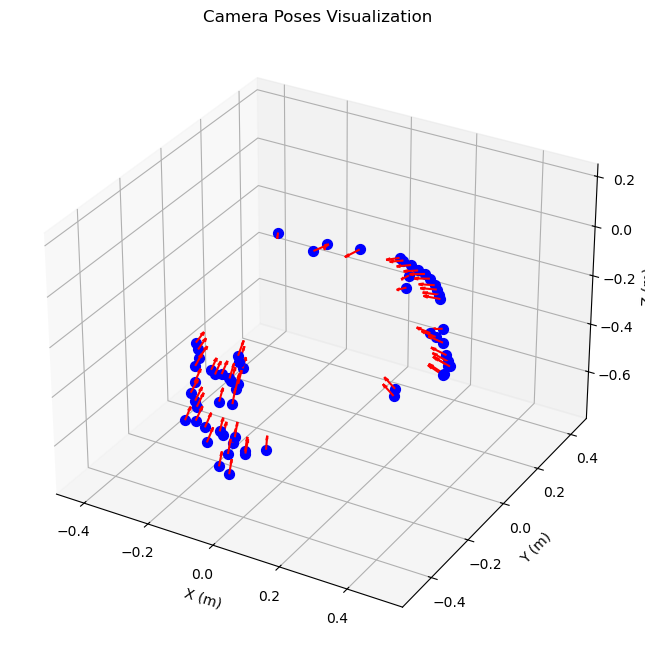

Poses visualization saved to poses_visualization.png

Running pose verification...


In [7]:
if __name__ == "__main__":
    # Example usage
    object_images_folder = "final_miku_images"  # Change to your object images folder
    calibration_file = "camera_calibration.npz"
    poses_output = "camera_poses.json"
    
    # Estimate camera poses
    poses = estimate_poses(object_images_folder, calibration_file, 
                          tag_size=0.06, output_file=poses_output)
    
    if poses is not None:
        # Visualize camera poses
        visualize_poses(poses)
        
        # Quick verification
        print("\nRunning pose verification...")
        verify_pose_estimation(object_images_folder, calibration_file)

### Part 0.3: Estimating Camera Pose
Now that you have calibrated your camera, you can use those intrinsic parameters to estimate the camera pose (position and orientation) for each image of your object. As discussed in lecture, this is the classic Perspective-n-Point (PnP) problem: given a set of 3D points in world coordinates and their corresponding 2D projections in an image, we want to find the camera's extrinsic parameters (rotation and translation).

For each image in your object scan, you'll detect the single ArUco tag and use cv2.solvePnP() to estimate the camera pose. Here's what you need:

Inputs to solvePnP:

objectPoints (numpy array of shape (N, 3) or (N, 1, 3)): The 3D coordinates of the ArUco tag corners in world space. Since you know the physical size of your printed tag, you can define these coordinates. For example, if your tag is 0.02m × 0.02m, you might define the 4 corners as: [(0,0,0), (0.02,0,0), (0.02,0.02,0), (0,0.02,0)] in meters, with the tag lying flat on the z=0 plane.
imagePoints (numpy array of shape (N, 2) or (N, 1, 2)): The detected 2D pixel coordinates of the tag corners in the image (from detectMarkers()). You'll need to reshape the corners array from detectMarkers to match this shape.
cameraMatrix (numpy array of shape (3, 3)): The intrinsic matrix K that you computed in Part 0.1 (contains focal length and principal point)
distCoeffs (numpy array or None): The distortion coefficients from calibration
Output from solvePnP:

success (bool): Whether the pose estimation succeeded
rvec (numpy array of shape (3, 1)): Axis-Angle rotation vector (can be converted to a 3×3 rotation matrix using cv2.Rodrigues())
tvec (numpy array of shape (3, 1)): Translation vector
Together, the rotation matrix R (from rvec) and translation vector tvec form the camera's extrinsic matrix, which describes where the camera is positioned and oriented relative to the ArUco tag's coordinate system (which we're treating as the world origin).

Important: Just like in Part 0.1, make sure your code handles cases where the tag isn't detected in some images. You should skip those images rather than letting your code crash.

To help visualize your pose estimation results, you can use the following code snippet to display a camera frustum in 3D (pip install viser):

In [8]:
pip install viser

Note: you may need to restart the kernel to use updated packages.


### Original below

In [9]:
import cv2
import numpy as np
import glob
import os
import json
import time
import viser

def estimate_camera_poses(images_path, calibration_file, tag_size=0.06):
    """
    Estimate camera poses for object scan images using ArUco tag and PnP
    """
    # Load camera calibration
    calibration_data = np.load(calibration_file)
    camera_matrix = calibration_data['camera_matrix']
    dist_coeffs = calibration_data['dist_coeffs']
    
    # Create ArUco detector
    aruco_dict = cv2.aruco.getPredefinedDictionary(cv2.aruco.DICT_4X4_50)
    aruco_params = cv2.aruco.DetectorParameters()
    detector = cv2.aruco.ArucoDetector(aruco_dict, aruco_params)
    
    # Define 3D coordinates of ArUco tag corners in world space
    # Tag lies flat on z=0 plane
    object_points = np.array([
        [0, 0, 0],           # bottom-left
        [tag_size, 0, 0],    # bottom-right
        [tag_size, tag_size, 0],  # top-right
        [0, tag_size, 0]     # top-left
    ], dtype=np.float32)
    
    # Get image files
    image_files = sorted(glob.glob(os.path.join(images_path, "*.jpg")) + 
                        glob.glob(os.path.join(images_path, "*.png")) +
                        glob.glob(os.path.join(images_path, "*.jpeg")))
    
    print(f"Found {len(image_files)} images for pose estimation")
    
    camera_data = []
    valid_images = 0
    
    for i, image_file in enumerate(image_files):
        print(f"Processing {i+1}/{len(image_files)}: {os.path.basename(image_file)}")
        
        # Read image
        image = cv2.imread(image_file)
        if image is None:
            print(f"  Could not read image, skipping")
            continue
            
        H, W = image.shape[:2]
        gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
        
        # Detect ArUco markers
        corners, ids, _ = detector.detectMarkers(gray)
        
        # Check if at least one tag detected
        if ids is not None and len(ids) >= 1:
            # Reshape corners to match solvePnP input format
            image_points = corners[0].reshape(4, 2).astype(np.float32)
            
            # Estimate camera pose using solvePnP
            success, rvec, tvec = cv2.solvePnP(
                object_points, 
                image_points, 
                camera_matrix, 
                dist_coeffs
            )
            
            if success:
                # Convert rotation vector to rotation matrix
                R, _ = cv2.Rodrigues(rvec)
                
                # Create camera-to-world transformation matrix (3x4)
                # First create world-to-camera matrix, then invert
                w2c = np.eye(4)
                w2c[:3, :3] = R
                w2c[:3, 3] = tvec.reshape(3)
                
                # Invert to get camera-to-world
                c2w = np.linalg.inv(w2c)
                
                camera_data.append({
                    'image_path': image_file,
                    'image': image,
                    'c2w': c2w[:3, :],  # 3x4 camera-to-world matrix
                    'K': camera_matrix,
                    'width': W,
                    'height': H,
                    'rvec': rvec,
                    'tvec': tvec
                })
                
                valid_images += 1
                print(f"  ✓ Pose estimated successfully")
                
                # Visualize detection
                image_with_markers = cv2.aruco.drawDetectedMarkers(image.copy(), corners, ids)
                image_with_axes = cv2.drawFrameAxes(image_with_markers, camera_matrix, dist_coeffs, 
                                                   rvec, tvec, tag_size/2)
                # cv2.imshow('Pose Estimation', image_with_axes)
                # cv2.waitKey(100)
                import matplotlib.pyplot as plt
                # plt.imshow(cv2.cvtColor(image_with_axes, cv2.COLOR_BGR2RGB))
                # plt.title(f"Pose Estimation - {os.path.basename(image_file)}")
                # plt.axis("off")
                # plt.show()

            else:
                print(f"  ✗ Pose estimation failed")
        else:
            if ids is None:
                print(f"  ✗ No ArUco tag detected")
            else:
                print(f"  ✗ Found {len(ids)} tags, expected 1")
    
    # cv2.destroyAllWindows()
    print(f"\nSuccessfully estimated poses for {valid_images}/{len(image_files)} images")
    return camera_data

def visualize_camera_frustums(camera_data):
    """
    Visualize camera poses using Viser (as provided in the assignment)
    """
    try:
        import viser
        import numpy as np
    except ImportError:
        print("Installing viser...")
        import subprocess
        import sys
        subprocess.check_call([sys.executable, "-m", "pip", "install", "viser"])
        
        import viser
        import numpy as np
    
    # Create Viser server
    server = viser.ViserServer(share=True)
    
    print("Starting Viser visualization...")
    print("Check your browser for the visualization interface")
    
    # Add coordinate axes at origin
    server.scene.add_frame(
        "/origin",
        wxyz=(1.0, 0.0, 0.0, 0.0),
        position=(0.0, 0.0, 0.0),
        # axis_length=0.1,
        # scale=0.1,
    )

    # Add ArUco tag plane representation
    server.scene.add_box(
        "/aruco_tag",
        dimensions=(0.06, 0.06, 0.001),  # 6cm x 6cm x 1mm
        wxyz=(1.0, 0.0, 0.0, 0.0),
        position=(0.0, 0.0, 0.0),
        color=(255, 255, 255),  # Change to RGB tuple
    )
    
    # Add each camera frustum
    for i, cam in enumerate(camera_data):
        c2w = cam['c2w']
        K = cam['K']
        H = cam['height']
        W = cam['width']
        img = cam['image']
        
        # Calculate field of view (using the formula from assignment)
        fov = 2 * np.arctan2(H / 2, K[0, 0])
        aspect = W / H
        
        # Add camera frustum (using exact code from assignment)
        server.scene.add_camera_frustum(
            f"/cameras/{i}",
            fov=fov,
            aspect=aspect,
            scale=0.05,  # You can adjust this if too small/big
            wxyz=viser.transforms.SO3.from_matrix(c2w[:3, :3]).wxyz,
            position=c2w[:3, 3],
            image=img
        )
    
    print(f"Added {len(camera_data)} camera frustums to visualization")
    print("Take screenshots for your deliverables from different viewpoints")
    print("The server will keep running until you press Ctrl+C")
    
    # Keep server running (as provided in assignment)
    try:
        while True:
            time.sleep(0.1)
    except KeyboardInterrupt:
        print("\nShutting down visualization server")

def save_camera_poses(camera_data, output_file="camera_poses.json"):
    """Save camera poses to JSON file for later use"""
    poses_dict = {}
    
    for i, cam in enumerate(camera_data):
        poses_dict[os.path.basename(cam['image_path'])] = {
            'c2w': cam['c2w'].tolist(),
            'K': cam['K'].tolist(),
            'image_size': [cam['width'], cam['height']],
            'rvec': cam['rvec'].reshape(-1).tolist(),
            'tvec': cam['tvec'].reshape(-1).tolist()
        }
    
    with open(output_file, 'w') as f:
        json.dump(poses_dict, f, indent=2)
    
    print(f"Camera poses saved to {output_file}")

if __name__ == "__main__":
    # Configuration
    OBJECT_IMAGES_PATH = "final_miku_images"  # Update this path
    CALIBRATION_FILE = "camera_calibration.npz"
    TAG_SIZE = 0.06  # 60mm in meters
    
    # Step 1: Estimate camera poses
    print("=== Part 0.3: Estimating Camera Poses ===")
    camera_data = estimate_camera_poses(OBJECT_IMAGES_PATH, CALIBRATION_FILE, TAG_SIZE)
    
    if not camera_data:
        print("No valid camera poses estimated. Check your images and ArUco tag placement.")
        exit(1)
    
    # Step 2: Save poses
    save_camera_poses(camera_data)
    
    # Step 3: Visualize with Viser
    print("\n=== Starting Viser Visualization ===")
    visualize_camera_frustums(camera_data)

=== Part 0.3: Estimating Camera Poses ===
Found 64 images for pose estimation
Processing 1/64: IMG_2254.jpg
  ✓ Pose estimated successfully
Processing 2/64: IMG_2255.jpg
  ✓ Pose estimated successfully
Processing 3/64: IMG_2256.jpg
  ✓ Pose estimated successfully
Processing 4/64: IMG_2257.jpg
  ✓ Pose estimated successfully
Processing 5/64: IMG_2258.jpg
  ✓ Pose estimated successfully
Processing 6/64: IMG_2259.jpg
  ✓ Pose estimated successfully
Processing 7/64: IMG_2260.jpg
  ✓ Pose estimated successfully
Processing 8/64: IMG_2261.jpg
  ✓ Pose estimated successfully
Processing 9/64: IMG_2262.jpg
  ✓ Pose estimated successfully
Processing 10/64: IMG_2263.jpg
  ✓ Pose estimated successfully
Processing 11/64: IMG_2264.jpg
  ✓ Pose estimated successfully
Processing 12/64: IMG_2265.jpg
  ✓ Pose estimated successfully
Processing 13/64: IMG_2266.jpg
  ✓ Pose estimated successfully
Processing 14/64: IMG_2267.jpg
  ✓ Pose estimated successfully
Processing 15/64: IMG_2268.jpg
  ✓ Pose estimated

╭────── viser (listening *:8080) ───────╮
│             ╷                         │
│   HTTP      │ http://localhost:8080   │
│   Websocket │ ws://localhost:8080     │
│             ╵                         │
╰───────────────────────────────────────╯

(viser) Share URL requested!

(viser) Generated share URL (expires in 24 hours, max 16 clients): https://focus-eye.share.viser.studio

Starting Viser visualization...
Check your browser for the visualization interface


(viser) Connection opened (0, 1 total), 146 persistent messages

Added 63 camera frustums to visualization
Take screenshots for your deliverables from different viewpoints
The server will keep running until you press Ctrl+C

Shutting down visualization server


(viser) Connection closed (0, 0 total)

### Part 0.4: Undistorting images and creating a dataset
Now that you have the camera intrinsics and pose estimates, the final step is to undistort your images and package everything into a dataset format that you can use for training NeRF in the later parts of this project.

First, use cv2.undistort() to remove any lens distortion from your images. This is important because NeRF assumes a perfect pinhole camera model without distortion.

import cv2

# Undistort an image using the calibration results
undistorted_img = cv2.undistort(img, camera_matrix, dist_coeffs)
After undistorting all your images, you'll need to save everything in a .npz file format that matches what's expected for the NeRF training code. You should split your images into training, validation, and test sets, then save using the following keys:

images_train: numpy array of shape (N_train, H, W, 3) containing your undistorted training images (0-255 range, will be normalized when loaded)
c2ws_train: numpy array of shape (N_train, 4, 4) containing the camera-to-world transformation matrices for training images
images_val: numpy array of shape (N_val, H, W, 3) for validation images
c2ws_val: numpy array of shape (N_val, 4, 4) for validation camera poses
c2ws_test: numpy array of shape (N_test, 4, 4) for test camera poses (used for novel view rendering)
focal: float representing the focal length from your camera intrinsics (assuming fx = fy)
You can save your dataset using np.savez():

In [ ]:
import cv2
import numpy as np
import json
import os
from sklearn.model_selection import train_test_split

def create_nerf_dataset(camera_poses_file, calibration_file, images_path, output_file="my_nerf_data.npz", test_size=0.2, val_size=0.1):
    """
    Create NeRF dataset from calibrated images and poses
    """
    # Load camera poses
    with open(camera_poses_file, 'r') as f:
        camera_poses = json.load(f)
    
    # Load camera calibration
    calibration_data = np.load(calibration_file)
    camera_matrix = calibration_data['camera_matrix']
    dist_coeffs = calibration_data['dist_coeffs']
    
    # Extract focal length (assuming fx = fy)
    focal = camera_matrix[0, 0]
    
    # Prepare data arrays
    images = []
    c2ws = []
    valid_files = []
    
    print("Processing images and poses...")
    
    for img_name, pose_data in camera_poses.items():
        img_path = os.path.join(images_path, img_name)
        
        if not os.path.exists(img_path):
            print(f"Warning: Image {img_path} not found, skipping")
            continue
        
        # Load and undistort image
        img = cv2.imread(img_path)
        if img is None:
            print(f"Warning: Could not read {img_path}, skipping")
            continue
        
        # Convert BGR to RGB
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        
        # Undistort image
        undistorted_img = cv2.undistort(img_rgb, camera_matrix, dist_coeffs)
        
        # Get camera-to-world matrix (ensure it's 4x4)
        # c2w = np.array(pose_data['cam2world'])
        # With this (check for different possible keys):
        if 'cam2world' in pose_data:
            c2w = np.array(pose_data['cam2world'])
        elif 'c2w' in pose_data:
            c2w = np.array(pose_data['c2w'])
        elif 'camera_to_world' in pose_data:
            c2w = np.array(pose_data['camera_to_world'])
        else:
            # Print available keys to debug
            print(f"Available keys: {list(pose_data.keys())}")
            continue  # Skip this image
        if c2w.shape == (3, 4):
            # Convert 3x4 to 4x4
            c2w_4x4 = np.eye(4)
            c2w_4x4[:3, :] = c2w
        else:
            c2w_4x4 = c2w
        
        images.append(undistorted_img)
        c2ws.append(c2w_4x4)
        valid_files.append(img_name)
    
    if not images:
        print("No valid images found!")
        return
    
    # Convert to numpy arrays
    images = np.array(images)  # Shape: (N, H, W, 3)
    c2ws = np.array(c2ws)      # Shape: (N, 4, 4)
    
    print(f"Processed {len(images)} images")
    print(f"Image shape: {images[0].shape}")
    print(f"Camera poses shape: {c2ws[0].shape}")
    
    # Split data: train, val, test
    # First split: separate test set
    train_val_idx, test_idx = train_test_split(
        range(len(images)), 
        test_size=test_size, 
        random_state=180
    )
    
    # Second split: separate train and val from remaining
    train_idx, val_idx = train_test_split(
        train_val_idx, 
        test_size=val_size/(1-test_size), 
        random_state=180
    )
    
    # Create splits
    images_train = images[train_idx]
    c2ws_train = c2ws[train_idx]
    
    images_val = images[val_idx]
    c2ws_val = c2ws[val_idx]
    
    c2ws_test = c2ws[test_idx]
    
    print(f"\nDataset splits:")
    print(f"Training: {len(images_train)} images")
    print(f"Validation: {len(images_val)} images") 
    print(f"Test: {len(c2ws_test)} poses")
    print(f"Focal length: {focal:.2f}")
    
    # Save dataset
    np.savez(
        output_file,
        images_train=images_train,    # (N_train, H, W, 3)
        c2ws_train=c2ws_train,        # (N_train, 4, 4)
        images_val=images_val,        # (N_val, H, W, 3)
        c2ws_val=c2ws_val,            # (N_val, 4, 4)
        c2ws_test=c2ws_test,          # (N_test, 4, 4)
        focal=focal                   # float
    )
    
    print(f"\nNeRF dataset saved to {output_file}")
    
    # Save split information for reference
    split_info = {
        'train_files': [valid_files[i] for i in train_idx],
        'val_files': [valid_files[i] for i in val_idx],
        'test_files': [valid_files[i] for i in test_idx],
        'focal_length': focal
    }
    
    with open('dataset_splits.json', 'w') as f:
        json.dump(split_info, f, indent=2)
    
    return output_file

def verify_dataset(dataset_file):
    """Verify the created dataset"""
    data = np.load(dataset_file)
    
    print(f"\n=== Dataset Verification ===")
    print(f"images_train: {data['images_train'].shape} (dtype: {data['images_train'].dtype})")
    print(f"c2ws_train: {data['c2ws_train'].shape}")
    print(f"images_val: {data['images_val'].shape}")
    print(f"c2ws_val: {data['c2ws_val'].shape}")
    print(f"c2ws_test: {data['c2ws_test'].shape}")
    print(f"focal: {data['focal']}")
    
    # Check value ranges
    print(f"\nImage value range: [{data['images_train'].min():.1f}, {data['images_train'].max():.1f}]")
    print("✓ Images should be in 0-255 range")
    
    # Check camera poses
    print(f"\nCamera pose norms:")
    print(f"Train: min={np.linalg.norm(data['c2ws_train'][:, :3, 3], axis=1).min():.3f}, "
          f"max={np.linalg.norm(data['c2ws_train'][:, :3, 3], axis=1).max():.3f}")
    
    return data

if __name__ == "__main__":
    # Configuration
    CAMERA_POSES_FILE = "camera_poses.json"
    CALIBRATION_FILE = "camera_calibration.npz"
    IMAGES_PATH = "miku-images"
    OUTPUT_FILE = "my_nerf_data.npz"
    
    # Create NeRF dataset
    print("=== Part 0.4: Creating NeRF Dataset ===")
    dataset_path = create_nerf_dataset(
        CAMERA_POSES_FILE,
        CALIBRATION_FILE, 
        IMAGES_PATH,
        output_file=OUTPUT_FILE,
        test_size=0.2,    # 20% for test
        val_size=0.1      # 10% for validation
    )
    
    if dataset_path:
        # Verify the dataset
        verify_dataset(dataset_path)
        
        print(f"\n✅ Dataset creation complete!")
        print(f"Your dataset '{OUTPUT_FILE}' is ready for NeRF training!")
        print(f"Split information saved to 'dataset_splits.json'")

=== Part 0.4: Creating NeRF Dataset ===
Processing images and poses...


MemoryError: Unable to allocate 1.09 GiB for an array with shape (32, 4032, 3024, 3) and data type uint8

(viser) Connection closed (0, 0 total)